In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("loan_approval_data.csv")
print()

In [3]:
df.head()
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,501.220000,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,289.608451,5061.632859,2943.161570,11.139797,1.105067,71.346015,1.406246,0.144341,5860.736885,14345.696031,11504.142575,24.245322
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,250.250000,6730.750000,2472.750000,30.250000,1.000000,616.250000,1.000000,0.220000,4760.250000,12698.250000,9806.250000,24.000000
50%,499.500000,10548.000000,5205.500000,40.000000,1.000000,678.000000,2.000000,0.340000,9880.500000,24321.000000,21210.500000,48.000000
75%,752.750000,15190.000000,7620.750000,49.000000,2.000000,737.000000,3.000000,0.480000,15074.500000,36947.000000,30263.000000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


In [4]:
categorical_cols = df.select_dtypes(include=["object"]).columns
numerical_cols = df.select_dtypes(include=["number"]).columns

In [5]:
print(numerical_cols)

Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income', 'Age',
       'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term'],
      dtype='object')


In [6]:
from sklearn.impute import SimpleImputer

num_imp = SimpleImputer(strategy="mean")
df[numerical_cols] = num_imp.fit_transform(df[numerical_cols])

In [7]:
cat_imp = SimpleImputer(strategy="most_frequent")
df[categorical_cols] = cat_imp.fit_transform(df[categorical_cols])

In [8]:
df.head()
df.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

Text(0.5, 1.0, 'Is Lone approved or not')

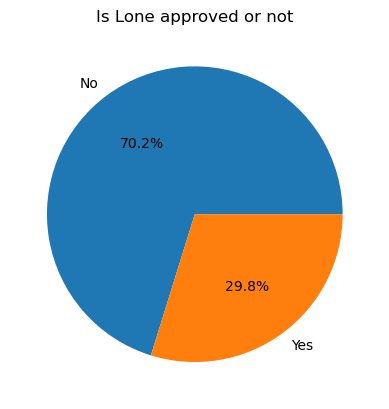

In [9]:
classes_count =  df["Loan_Approved"].value_counts()

plt.pie(classes_count, labels = ["No", "Yes"], autopct = "%1.1f%%")
plt.title("Is Lone approved or not")

[Text(0, 0, '722'), Text(0, 0, '278')]

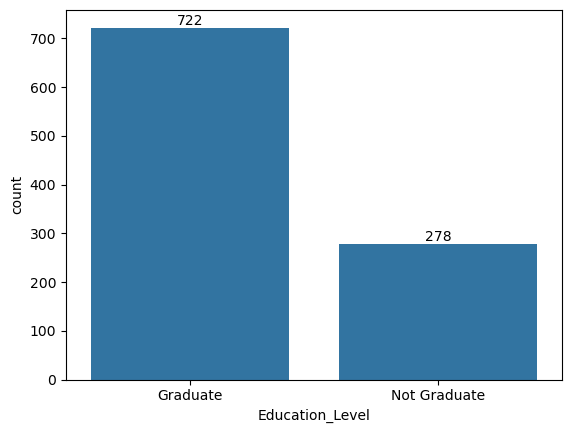

In [10]:
edu_cnt = df["Education_Level"].value_counts()
x = sns.barplot(edu_cnt)
x.bar_label(x.containers[0])

In [11]:
# df.head()
# df.columns
# df.info()
df.head(25)

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.00,17795.0,1387.000000,Salaried,51.0,Married,0.0,637.0,4.000000,0.530000,19403.000000,45638.000000,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.00,2860.0,2679.000000,Salaried,46.0,Married,3.0,621.0,2.000000,0.300000,2580.000000,49272.000000,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.00,7390.0,2106.000000,Salaried,25.0,Single,2.0,674.0,4.000000,0.200000,13844.000000,6908.000000,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.00,13964.0,8173.000000,Salaried,40.0,Married,2.0,579.0,3.000000,0.310000,9553.000000,10844.000000,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.00,13284.0,4223.000000,Self-employed,31.0,Single,2.0,721.0,1.000000,0.290000,9386.000000,37629.000000,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes
5,6.00,8265.0,4831.000000,Salaried,53.0,Single,1.0,602.0,1.000000,0.560000,19522.000000,2911.000000,9798.0,36.0,Home,Semiurban,Graduate,Male,Unemployed,No
6,7.00,18850.0,2768.000000,Salaried,58.0,Married,0.0,687.0,0.000000,0.480000,14635.000000,8991.000000,26143.0,24.0,Home,Rural,Graduate,Male,Private,No
7,8.00,6426.0,3186.000000,Salaried,47.0,Married,2.0,636.0,4.000000,0.347263,671.000000,11572.000000,33747.0,84.0,Personal,Rural,Graduate,Female,Private,No
8,9.00,16423.0,5082.455789,Salaried,54.0,Married,1.0,729.0,0.000000,0.590000,777.000000,43066.000000,34651.0,36.0,Home,Semiurban,Graduate,Male,Private,No
9,10.00,13363.0,2599.000000,Contract,35.0,Single,3.0,726.0,1.000000,0.347263,3022.000000,29693.000000,22182.0,60.0,Personal,Rural,Graduate,Female,Government,Yes


In [12]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

le = LabelEncoder()
df["Education_Level"] = le.fit_transform(df["Education_Level"])
df["Loan_Approved"] = le.fit_transform(df["Loan_Approved"])

In [13]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,1,Female,Private,0
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,0,Male,Private,0
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,0,Female,Government,1
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,0,Female,Government,0
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,0,Male,Private,1


In [14]:
col = ["Employment_Status", "Marital_Status", "Loan_Purpose", "Gender","Property_Area", "Employer_Category"]

ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")
encoded = ohe.fit_transform(df[col])
encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(col), index=df.index)
df = pd.concat([df.drop(columns=col), encoded_df], axis=1)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 29 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_ID                     1000 non-null   float64
 1   Applicant_Income                 1000 non-null   float64
 2   Coapplicant_Income               1000 non-null   float64
 3   Age                              1000 non-null   float64
 4   Dependents                       1000 non-null   float64
 5   Credit_Score                     1000 non-null   float64
 6   Existing_Loans                   1000 non-null   float64
 7   DTI_Ratio                        1000 non-null   float64
 8   Savings                          1000 non-null   float64
 9   Collateral_Value                 1000 non-null   float64
 10  Loan_Amount                      1000 non-null   float64
 11  Loan_Term                        1000 non-null   float64
 12  Education_Level      

<Axes: >

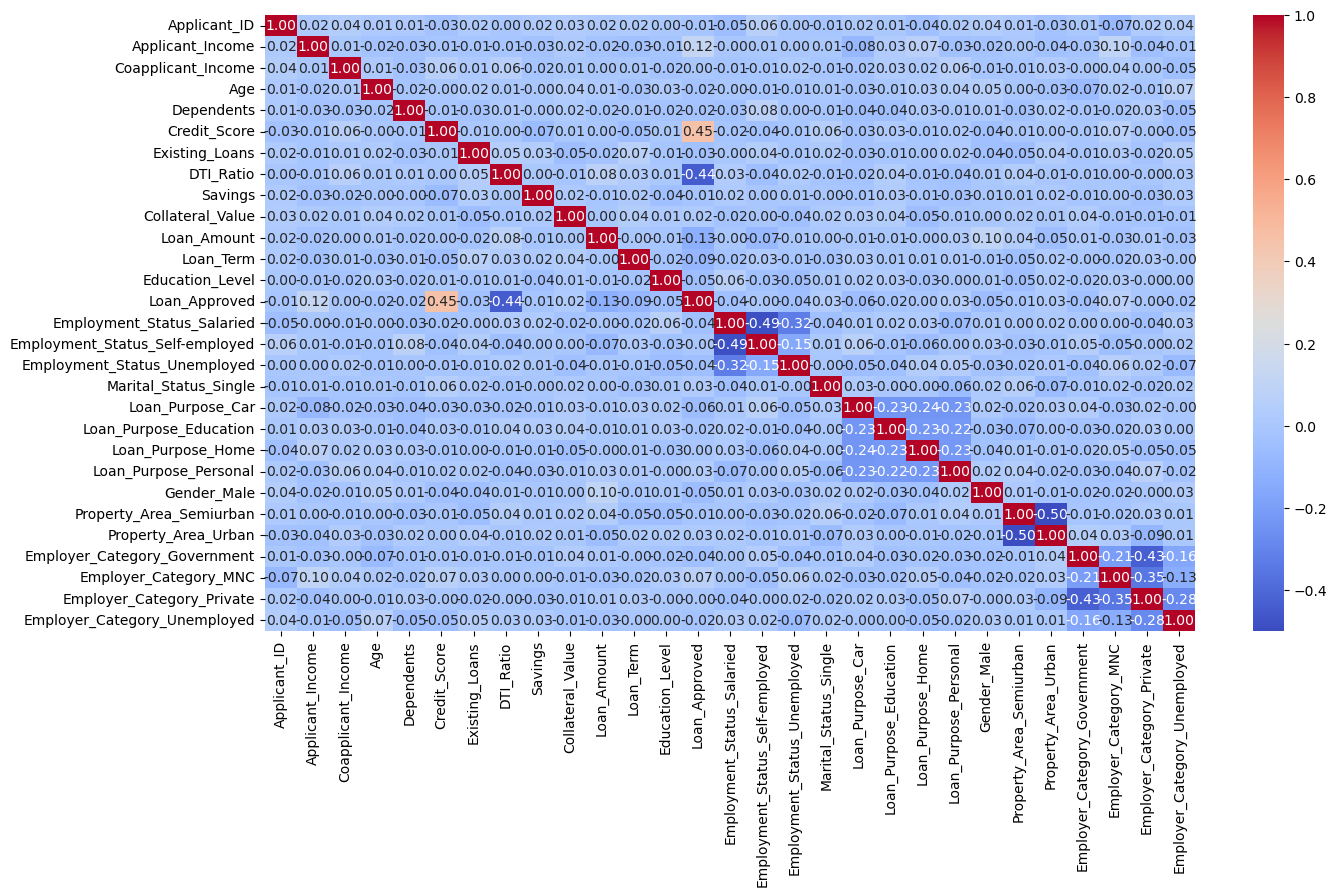

In [16]:
num_cols = df.select_dtypes(include="number")
corr_matrix = num_cols.corr()

plt.figure(figsize=(15, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f", 
    cmap="coolwarm"
)

In [17]:
 num_cols.corr()["Loan_Approved"].sort_values(ascending=False)

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Applicant_ID                      -0.011167
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed    

In [18]:
X = df.drop(["Loan_Approved","Applicant_ID"], axis=1)
Y = df["Loan_Approved"]

In [19]:
X.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Gender_Male,Property_Area_Semiurban,Property_Area_Urban,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0


In [20]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [22]:
print(X_train.columns)




Index(['Applicant_Income', 'Coapplicant_Income', 'Age', 'Dependents',
       'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term', 'Education_Level',
       'Employment_Status_Salaried', 'Employment_Status_Self-employed',
       'Employment_Status_Unemployed', 'Marital_Status_Single',
       'Loan_Purpose_Car', 'Loan_Purpose_Education', 'Loan_Purpose_Home',
       'Loan_Purpose_Personal', 'Gender_Male', 'Property_Area_Semiurban',
       'Property_Area_Urban', 'Employer_Category_Government',
       'Employer_Category_MNC', 'Employer_Category_Private',
       'Employer_Category_Unemployed'],
      dtype='object')


In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [24]:
#  LOGISTIC REGRESSION
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
log_model = LogisticRegression()
log_model.fit(X_train_scaled, Y_train)

Y_pred = log_model.predict(X_test_scaled)

# EVALUATION
print("accuracy_score", accuracy_score(Y_test, Y_pred))
print("confusion_matrix", confusion_matrix(Y_test, Y_pred))


Logistic Regression Model
Precision 0.7833333333333333
recoll 0.7704918032786885
fi score 0.7768595041322314
accuracy_score 0.865
confusion_matrix [[126  13]
 [ 14  47]]
[0 0 0 1 0 1 0 0 0 0 0 0 1 0 1 0 0 0 0 1 1 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0
 0 0 0 1 0 0 1 1 0 1 0 0 0 0 1 1 0 0 0 0 1 0 0 0 0 0 1 1 1 0 0 0 0 1 1 0 0
 1 0 0 0 1 0 0 1 1 1 0 0 1 1 1 0 0 1 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0 0 0 0
 1 0 0 1 0 0 0 1 0 0 0 0 1 0 0 1 0 0 1 0 1 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 1
 1 0 0 0 0 1 0 0 1 0 0 1 1 0 1 0 0 1 0 0 1 0 1 0 0 0 1 0 1 0 0 1 1 0 0 0 0
 0 1 1 0 0 0 0 0 0 0 0 0 1 0 0]


In [25]:
import joblib

joblib.dump(log_model, "model.pkl")

['model.pkl']

In [26]:
import joblib

joblib.dump(le, "label_encoder.pkl")
joblib.dump(ohe, "onehot_encoder.pkl")
joblib.dump(log_model, "model.pkl")

['model.pkl']

In [27]:
import joblib
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [173]:
print(X_train.columns)

Index(['Applicant_Income', 'Coapplicant_Income', 'Age', 'Dependents',
       'Existing_Loans', 'Savings', 'Collateral_Value', 'Loan_Amount',
       'Loan_Term', 'Education_Level', 'Employment_Status_Salaried',
       'Employment_Status_Self-employed', 'Employment_Status_Unemployed',
       'Marital_Status_Single', 'Loan_Purpose_Car', 'Loan_Purpose_Education',
       'Loan_Purpose_Home', 'Loan_Purpose_Personal', 'Gender_Male',
       'Property_Area_Semiurban', 'Property_Area_Urban',
       'Employer_Category_Government', 'Employer_Category_MNC',
       'Employer_Category_Private', 'Employer_Category_Unemployed',
       'DTI_Ratio_sq', 'Credit_Score_sq'],
      dtype='object')
